In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("student_performance.csv", encoding="latin1")

df.head()

,fNAME,lNAME,Age,gender,country,residence,entryEXAM,prevEducation,studyHOURS,Python,DB
0,Christina,Binger,44,Female,Norway,Private,72,Masters,158,59.0,55
1,Alex,Walekhwa,60,M,Kenya,Private,79,Diploma,150,60.0,75
2,Philip,Leo,25,Male,Uganda,Sognsvann,55,HighSchool,130,74.0,50
3,Shoni,Hlongwane,22,F,Rsa,Sognsvann,40,High School,120,NaN,44
4,Maria,Kedibone,23,Female,South Africa,Sognsvann,65,High School,122,91.0,80


In [2]:
df.isnull().sum()

df = df.dropna()

In [3]:
df["Pass_Fail"] = df["entryEXAM"].apply(lambda x: "Pass" if x >= 50 else "Fail")

df.head()

,fNAME,lNAME,Age,gender,country,residence,entryEXAM,prevEducation,studyHOURS,Python,DB,Pass_Fail
0,Christina,Binger,44,Female,Norway,Private,72,Masters,158,59.0,55,Pass
1,Alex,Walekhwa,60,M,Kenya,Private,79,Diploma,150,60.0,75,Pass
2,Philip,Leo,25,Male,Uganda,Sognsvann,55,HighSchool,130,74.0,50,Pass
4,Maria,Kedibone,23,Female,South Africa,Sognsvann,65,High School,122,91.0,80,Pass
5,Hannah,Hansen,25,female,Norge,BI Residence,66,High School,130,88.0,59,Pass


In [4]:
corr = df[["entryEXAM", "studyHOURS", "Python", "DB"]].corr()

print(corr)

            entryEXAM  studyHOURS    Python        DB
entryEXAM    1.000000    0.796708  0.787550  0.594018
studyHOURS   0.796708    1.000000  0.813826  0.442339
Python       0.787550    0.813826  1.000000  0.449401
DB           0.594018    0.442339  0.449401  1.000000


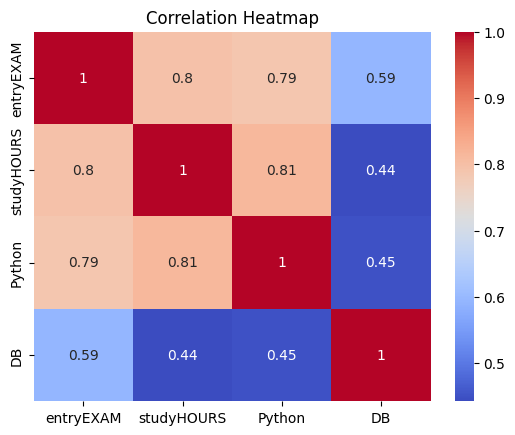

In [5]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [6]:
cov = df[["entryEXAM", "studyHOURS", "Python", "DB"]].cov()

print(cov)

             entryEXAM  studyHOURS      Python          DB
entryEXAM   259.125405  159.484324  195.364324  162.586486
studyHOURS  159.484324  154.642162  155.957838   93.529730
Python      195.364324  155.957838  237.478198  117.754054
DB          162.586486   93.529730  117.754054  289.108108


In [7]:
total = len(df)
print("Total Students:", total)

Total Students: 75


In [8]:
pass_count = len(df[df["Pass_Fail"] == "Pass"])

prob_pass = pass_count / total

print("P(Pass) =", prob_pass)

P(Pass) = 0.9333333333333333


In [9]:
fail_count = len(df[df["Pass_Fail"] == "Fail"])

prob_fail = fail_count / total

print("P(Fail) =", prob_fail)

P(Fail) = 0.06666666666666667


In [10]:
high_study = df[df["studyHOURS"] > 5]

if len(high_study) > 0:
    prob_cond = len(high_study[high_study["Pass_Fail"] == "Pass"]) / len(high_study)
    print("P(Pass | studyHOURS > 5) =", prob_cond)

P(Pass | studyHOURS > 5) = 0.9333333333333333


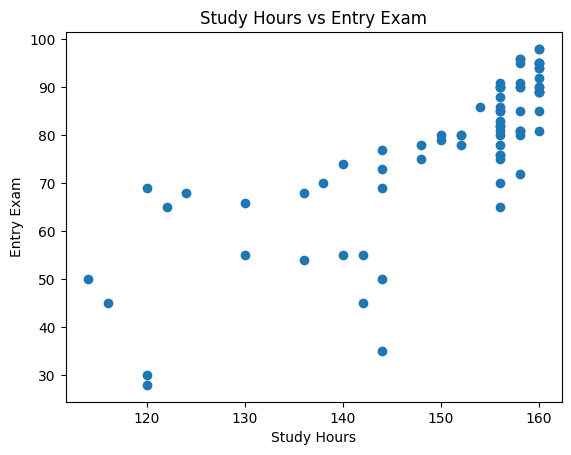

In [11]:
plt.scatter(df["studyHOURS"], df["entryEXAM"])
plt.title("Study Hours vs Entry Exam")
plt.xlabel("Study Hours")
plt.ylabel("Entry Exam")
plt.show()

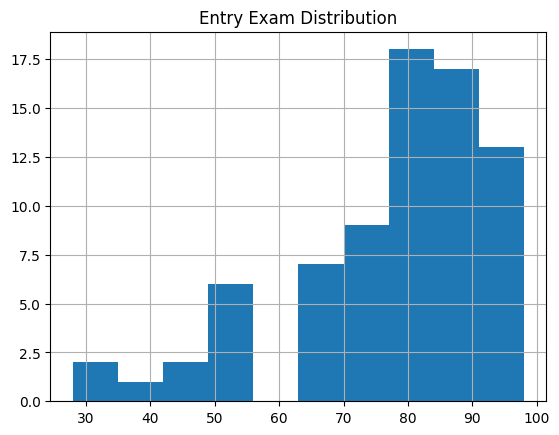

In [12]:
df["entryEXAM"].hist()
plt.title("Entry Exam Distribution")
plt.show()

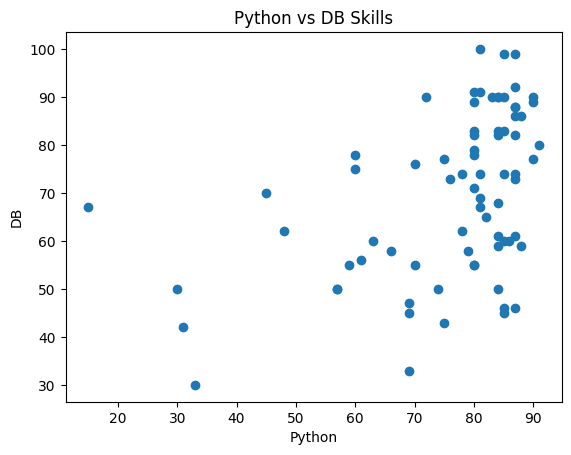

In [13]:
plt.scatter(df["Python"], df["DB"])
plt.title("Python vs DB Skills")
plt.xlabel("Python")
plt.ylabel("DB")
plt.show()